
<br>
<h1 align="center">MULTIMEDIA UNIVERSITY MALAYSIA</h1><br>
<h1 align="center">CDS6354 Machine Learning</h1>
<h3 align="center">Nov/Dec 2025 Trimester<br>
<h2 align="center">Group Assignment<br>
<h2 align="center">Topic: A Comparative Study of CNN-Based and Hybrid Classification Models for Flower Species Recognition<br>
<h3 align="center">Lecturer: Dr.Radiah Haque</h3>
<h3 align="center">Prepared by: Group 14<br>
<h3 align="center">Tutorial Section: TT9L & T11L<br>

<h4 align="center">Group Member<br>
<br>

| No. | Student ID   |        Student Name       |  Tutorial Section |  Contribution  |
|-----|--------------|---------------------------|-------------------|------|
|  1  |  1231303316  | Low Sam Yee        |              T11L            |  Data Preprocessing and Model 3  |
|  2  |  1221309486  | Ong Shi Min              |          TT9L          | Data Preprocessing and Model 3  |
|  3  |  1221305928  | Heng Javenn               |         TT9L          | Model 4 |
|  4  |  1221309076  | Bryan Leow Man Uu             |       TT9L        | Model 2 |
|  5  |  1221309078  | Lovin A/L K Balasubramaniam    |       T11L       | Model 1 |

<br>

**Introduction:** Flower recognition has important meaning in botany, ecology and agriculture. However, traditional flower recognition method usually manual depends on expert experience, not only time-consuming and labour-intensive, but also lower efficiency when handling large-scale data. As the development of computer vision and deep learning, using machine learning algorithms to conduct flower recognition became an efficient process.

This experiment aims to use the Oxford 102 Flower Dataset to evaluate the performance of convolutional neural networks in image classification through various machine learning and deep learning algorithms, with a focus on understanding how the algorithms learn efficient features from different shooting directions, species, and complex backgrounds to recognize flower species.

<br>

**Problem Statement:**
1. **Inter-class Similarity**: Many flower species share similar visual characteristics such as colour, shape, and texture, making it difficult to distinguish between them using traditional feature extraction methods.

2. **Model Selection:** Selecting a model may be challenging as each model differs greatly. Deep learning models contain different capabilities with respect to feature extraction and generalization ability. A proper systematic evaluation is required to obtain a comparison for selecting the most suitable model for each individual situation.  

Thus, it is necessary to perform a proper evaluation to compare each machine learning technique which will then help to identify which models' architecture is the most suitable for classifying flower species for the 102 Oxford Flower Dataset.  

<br>

**Objective:** The objective of this assignment is to determine which model is the most suitable for flower image classification. Data preparation pipeline will need to be designed; neural-network based classification models will be developed and evaluated for their abhorrent ability to recognize and separate between the 102 flower categories within the dataset. The model 1,2,3, and 4 in this project will be analyzed for their performance through accuracy metrics as well as visual inspections of predictions.  

<br>

**Overall Model Development and Training:**
- **Model 1:** Custom Convolutional Neural Network (CNN) implemented from scratch
- **Model 2:** Transfer Learning using ResNet50 (CNN-based) implemented with TensorFlow
- **Model 3:** Feature Extraction using MobileNet with Support Vector Machine (SVM) and Principal Component Analysis (PCA) for overfitting mitigation
- **Model 4:** Transfer Learning using ResNet18 with Multi-Layer Perceptron (MLP) classifier implemented in PyTorch

These models include a broad spectrum of approaches, ranging from basic neural networks and custom implementations to transfer learning and hybrid models, offering a comprehensive comparison for examining the performance of various deep learning models in complex image classification tasks.

# **1. Dataset & Methods**
## 1.1 Dataset Description
In this experiment, the Oxford 102 Flower Dataset will be used, which comprises 102 different flower classes. These images have significant difference in colour, morphology, size, camera shooting angle and backgrounds. Due to the presence of considerable variation within the classes and the similarity between the classes, the dataset is highly appropriate for testing the performance of machine learning and deep learning models with respect to the learning of features for the purpose of multi-class classification of images.

The major challenges associated with this dataset are the similarities in color and structure of various flowers and the presence of background noise and lighting effects associated with the nature of the shooting. Therefore, the models need to have good features extraction capabilities in case to distinguish various type of flowers effectively.

<br>

---


## 1.2 Data Loading and Preprocessing Strategy
Although all models were trained and tested with the same Oxford 102 Flower Dataset, the different approaches to implementation with different frameworks resulted in different ways of loading the datasets.

Model 1 is a custom CNN that is coded from scratch, unlike the high-level interfaces available in TensorFlow or PyTorch. As a result, Model 1 uses a different approach to load the dataset. This approach can have better control on the image input format and the normalization process, which in line with the coding logic of implementing neural networks from scratch.

Model 2 and Model 3 both run on TensorFlow, so the data loading works the same way for both. The images come in at the same resolution, with matching class labels and the same split between training and validation sets. This help in easier way to compare how well each model performs. Basic preprocessing like resizing and normalizing the flower images stays consistent across model 2 and model 3

Model 4 take different approach. It is built with PyTorch. PyTorch handle tensors and processes data differently compare to TensorFlow, so the data need to be loaded again using PyTorch's ImageFolder and DataLoader tools. Altough the technical setup is different, the dataset folder structure, image size, batch size, and class labels all match up with the other models stays the same.

Any performance differences are likely because of how the model are designed and trained instead of the dataset by keeping everything consistent.  

---


## 1.3 Import Library

In [ ]:
import os
import json
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, regularizers, models
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D, Input
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA


# **2. Model 1:** Custom Convolutional Neural Network (CNN) implemented from scratch **[CNN from Scratch]**

Model 1  use convolutional neural network (CNN) built from scratch to classify the flower images. It rely on the network to learn features autonomously without pre-trained models.

<br>

**Model Objectives**

- CNNs can automatically extract low-level to high-level features from images, such as color, texture, and shape. Therefore, they are suitable for processing large-scale datasets.

- The model may overfit as the dataset is too large. So, data augmentation and regularization (L2 + Dropout)  is implemented in order to improve the model’s generalization capabilities.

- The project examine how well a CNN built from scratch can learn and where it struggles when working with a large dataset with similar visual characteristics. The results are used as a starting point to compare with pre-trained models, which is model 2,3 and 4.

In [ ]:
import kagglehub   # Direct import from kaggle
path = kagglehub.dataset_download("nunenuh/pytorch-challange-flower-dataset")

Using Colab cache for faster access to the 'pytorch-challange-flower-dataset' dataset.


## 2.1 Data Preparation
Model 1 implements a CNN built from scratch, thus employing an **independent data loading approach** distinct from subsequent TensorFlow-based models.

- Data source: Oxford 102 Flower Dataset

- Image dimensions: 224×224

- Batch Size: 32

- Training/validation split: Utilizes the dataset's original train/valid folders

- Category Information: `class_names` stores flower categories, `num_classes` indicates total number of classes

This independent loading approach ensures data can be directly fed into the custom CNN and facilitates subsequent application of Normalization and Data Augmentation.


In [ ]:
# Load Dataset

image_size = (224, 224)
batch_size = 32

train_flowers = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/pytorch-challange-flower-dataset/dataset/train",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
)

valid_flowers = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/pytorch-challange-flower-dataset/dataset/valid",
    image_size=image_size,
    batch_size=batch_size,
)

class_names = train_flowers.class_names
num_classes = len(class_names)

print("Number of Classes in the dataset:", num_classes)

Found 6552 files belonging to 102 classes.
Found 818 files belonging to 102 classes.
Number of Classes in the dataset: 102


## 2.2 Data Preprocessing

Data preprocessing for model 1 involves: **Normalization** and **Data Augmentation**.  

- **Normalization**: Normalization scales the image pixels to the [0,1] range to shorten training convergence time as well as to stabilize the network weights.  

- **Data Augmentation**: Data augmentation helps to include training sample diversity by doing random horizontal flipping and slight rotations on the individual images. Additionally, scaling is implemented to improve the model's generalizability and reduce model overfitting.  

This ensures that the model is reliable in learning effective features when it comes to images with variable lighting conditions, orientations, and scales.

In [ ]:
# Normalization

normalisation_layer = layers.Rescaling(1./255)

train_flowers = train_flowers.map(lambda x, y: (normalisation_layer(x), y))
valid_flowers = valid_flowers.map(lambda x, y: (normalisation_layer(x), y))

In [ ]:
# Data Augmentation (For artificially increasing dataset diversity through random image transformation)
# Reduces overfitting

flowers_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

## 2.3 Model Architecture
Model 1 is a **Scratch CNN**. It is fully built from the top up and is designed entirely from scratch as a classification model for the Oxford 102 Flower Dataset.

Model Features and Design Approach:

- **Convolution Layer + Pooling Layer**: These layers aid in extracting image features and reducing spatial dimensions.

- **Fully Connected Layer + Softmax**: This layer helps to map convolutional features to probability distributions for all the 102 categories.

Improvements:

- **Data Augmentation**: Data augmentation is done to enhance training sample diversity and improve generalization of the dataset.  

- **L2 Regularization + Dropout**: These layers are implemented to help minimize as much overfitting as possible.

- **Early Stopping + ReduceLROnPlateau**: Optimize training process, prevents overfitting, and dynamically adjust learning rate

In [ ]:
# Build CNN model

model = models.Sequential([
    flowers_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile CNN model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_flowers,
    validation_data=valid_flowers,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 34s 119ms/step - accuracy: 0.0742 - loss: 4.2245 - val_accuracy: 0.1993 - val_loss: 3.2264
Epoch 2/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.2169 - loss: 3.1160 - val_accuracy: 0.3032 - val_loss: 2.7184
Epoch 3/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.3526 - loss: 2.5249 - val_accuracy: 0.3949 - val_loss: 2.3587
Epoch 4/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step - accuracy: 0.4473 - loss: 2.0775 - val_accuracy: 0.4658 - val_loss: 2.0436
Epoch 5/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - accuracy: 0.5214 - loss: 1.7636 - val_accuracy: 0.5000 - val_loss: 1.9793
Epoch 6/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - accuracy: 0.5837 - loss: 1.5182 - val_accuracy: 0.5244 - val_loss: 2.0141
Epoch 7/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - accuracy: 0.6235 - loss: 1.3519 - val_accuracy: 0.5697 - val_loss: 1.7656
Epoch 8/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - accuracy: 0.6824 - loss: 1.1587 -

In [ ]:
model.evaluate(valid_flowers)


26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.5982 - loss: 1.7820


[1.6633373498916626, 0.616136908531189]

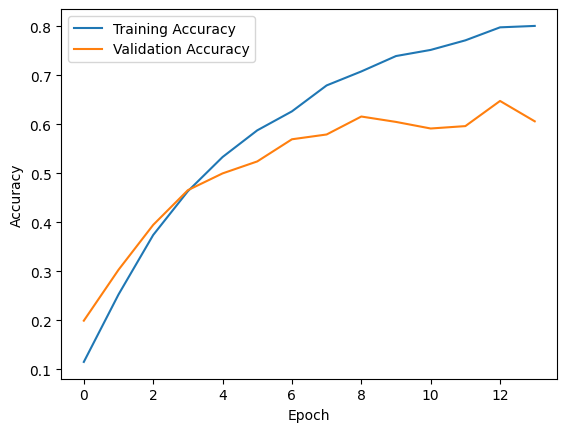

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# L2 regularization + Hyperparameter tuning

# Building the CNN model

from tensorflow.keras import regularizers

model = models.Sequential([
    flowers_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224,224,3),
                  kernel_regularizer=regularizers.l2(0.001)), # Added L2 regularisation
    layers.Dropout(0.5), # Added one more dropout layer here
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),  # Added L2 regularisation
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])



In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 102)            │        26,214 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,270,886 (84.96 MB)

 Trainable params: 22,270,886 (84.96 MB)

 Non-trainable params: 0 (0.00 B)

## 2.4 Training & Evaluation
The techniques below is implemented for Model 1：

<br>

1. **Early Stopping**:  

- Monitors validation set loss (val_loss), then stops the training early when no improvement whatsoever over a certain period  

- Help to prevent model overfitting problem and make the model training time shorter

<br>

2. **Learning Rate Scheduling (ReduceLROnPlateau)**:  

- The learning rate rescheduling method uses a periodically automated learning rate reduction algorithm that triggers when validation loss stops decreasing.  

- By utilizing this, the model prevents overshooting all the time while keeping the best results at the optimal point.  

<br>

3. **Training Results**:  

- Memorization problem appeared in the model. The model started to memorize training data which caused significant overfitting that led to high training accuracy but low validation accuracy.  

- To combat this problem, **L2 Regularization**, **Dropout layers** and **Learning Rate Rescheduling** is integrated to help improve validation accuracy.

- The final accuracy for the model’s validation training is approximately 52%.  

<br>

4. **Model Evaluation**:  

- Despite integrating **L2 Regularization**, **Dropout layers** and **Learning Rate Rescheduling**, the final validation accuracy only peaked at 51.9% with a loss of 2.19 which is not an improvement.  

- The overfitting issue of the model was fixed. However, it is apparent that this model, which is a Scratch CNN model, had its performance restricted by the model's capacity and training dataset which forced the model to underperform when compared to the CNN model with transfer learning.  

<br>

5. **Visualization**:  

- Accuracy curves is used to monitor how the model converged and pinpoint exactly where overfitting started.  

- The training accuracy and validation accuracy curves gradually converged after introducing regulation and learning rate adjustment. However, there are still slightly mitigating overfitting issues.

In [ ]:
early_stop = [
    tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,  # Change patience to 10 (Hyperparameter tuning)
    restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(  # add learning rate rescheduling
    monitor='val_loss',
    factor=0.3,
    patience=3,
    verbose=1
    )
]


history = model.fit(
    train_flowers,
    validation_data=valid_flowers,
    epochs=200,
    callbacks=[early_stop]
)

Epoch 1/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 27s 121ms/step - accuracy: 0.0280 - loss: 5.1972 - val_accuracy: 0.1015 - val_loss: 4.2368 - learning_rate: 0.0010
Epoch 2/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step - accuracy: 0.0886 - loss: 4.0573 - val_accuracy: 0.1198 - val_loss: 3.9052 - learning_rate: 0.0010
Epoch 3/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 112ms/step - accuracy: 0.1255 - loss: 3.7716 - val_accuracy: 0.1540 - val_loss: 3.6782 - learning_rate: 0.0010
Epoch 4/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 112ms/step - accuracy: 0.1366 - loss: 3.6136 - val_accuracy: 0.1822 - val_loss: 3.5297 - learning_rate: 0.0010
Epoch 5/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step - accuracy: 0.1754 - loss: 3.4629 - val_accuracy: 0.2237 - val_loss: 3.4149 - learning_rate: 0.0010
Epoch 6/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 24s 115ms/step - accuracy: 0.1992 - loss: 3.3384 - val_accuracy: 0.2543 - val_loss: 3.2562 - learning_rate: 0.0010
Epoch 7/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 112ms/step - accura

In [ ]:
model.evaluate(valid_flowers)

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.5462 - loss: 2.0642


[2.1943306922912598, 0.519559919834137]

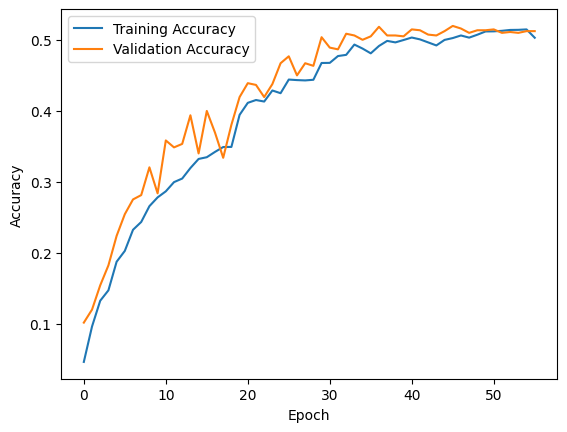

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 2.5 Summary
Model 1 serve as a baseline scratch CNN for flower classification. Although already applied  data augmentation, L2 regularization, dropout, and learning rate scheduling, the model shows limited generalization ability and only reach 52% validation accuracy. This result highlight the difficulty of training deep CNNs from scratch on large and complex image datasets and also motivate the adoption of transfer learning techniques in subsequent models.

# **3. Dataset Preparation and Parameter Setup for Models 2, 3 & 4**


## 3.1 Parameter Settings & Dataset Loading
> **The action restarting kernel after training model 1 is needed to avoid the dataset conflicts with model 2,3,and 4.**

It is because the augmentation and the normalization of model 2,3, and 4 is diffrent from model 1 as model 2,3 and 4 need pre-trained model-specific preprocessing which is ImageNet mean and std normalization

Global parameters include:

- **Image size**: 224 x 224 pixels. This is standardized to ensure input consistency across the various models.

- **Batch size**: The batch size is set to 32. This helps balance training speed and reduce memory consumption.

- **Random seed**: Ensures reproducibility of experimental results.

- **Data Path and Category Mapping**: Training set and Validation set are kept in separate directories. Each individual category from the dataset is numerically labelled, which are then mapped to human-readable flower names. This mapping is provided in the mapping file of the 102 Oxford Flower Dataset.  

Training data and validation data are loaded from directories with the exception for CNN from scratch model, which is imported from Kaggle. The subcategory of the dataset is stored in a separate subfolder. Other than that TensorFlow is utilized to automatically generate labels.

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

import kagglehub
path = kagglehub.dataset_download("nunenuh/pytorch-challange-flower-dataset")
train_dir = f"{path}/dataset/train"
val_dir   = f"{path}/dataset/valid"

with open(f"{path}/cat_to_name.json", "r") as f:
    cat_to_name = json.load(f)

class_names = sorted(cat_to_name.keys())
idx_to_name = {i: cat_to_name[cls] for i, cls in enumerate(class_names)}
num_classes = len(class_names)

print(f"Number of classes: {num_classes}")
print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")

Number of classes: 102
Image size: (224, 224)
Batch size: 32


In [ ]:
train_flowers = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    label_mode='int'
)

valid_flowers = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
    label_mode='int'
)

print(f"Training batches: {len(train_flowers)}")
print(f"Validation batches: {len(valid_flowers)}")

Found 6552 files belonging to 102 classes.
Found 818 files belonging to 102 classes.
Training batches: 205
Validation batches: 26


## 3.2 Dataset Visualization & Class Distribution
For a better understanding and visualization of the dataset, training images from the dataset are randomly displayed as well as the sample count for each category.

- **Image Display**: This shows the training images in a 3x3 grid with labeled category names for a clear data visualization.

- **Category Distribution Analysis**: An analysis of image count per category in the training set. This is done to identify any data imbalances which act as the necessary reference for any data augmentation and category weighting.

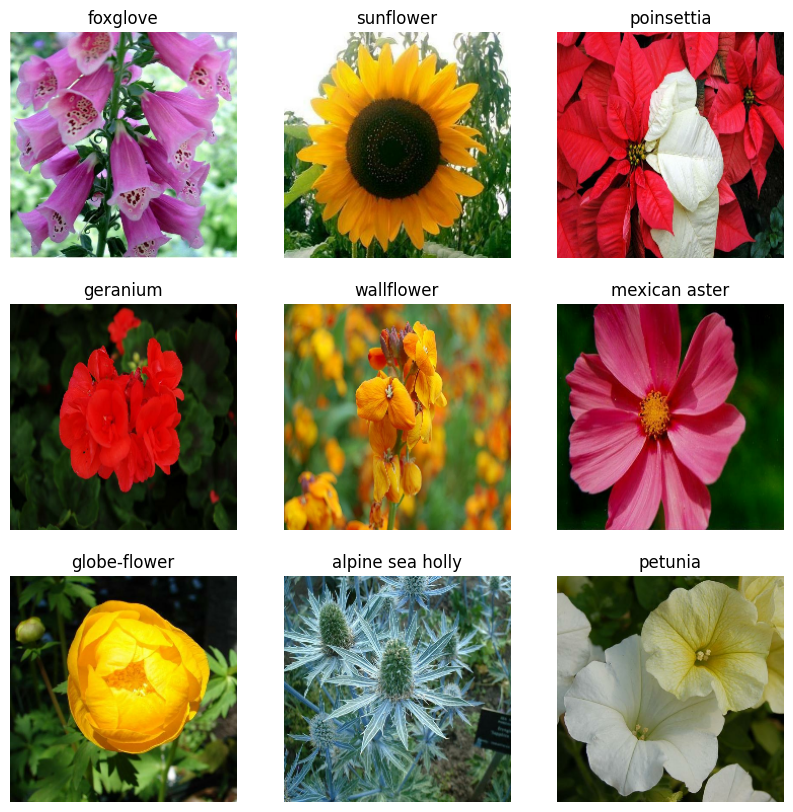

In [ ]:
def show_batch(dataset, idx_to_name, n=9):
    plt.figure(figsize=(10, 10))

    for images, labels in dataset.take(1):
        for i in range(n):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))

            label_idx = labels[i].numpy()
            plt.title(idx_to_name[label_idx])
            plt.axis("off")

show_batch(train_flowers, idx_to_name)

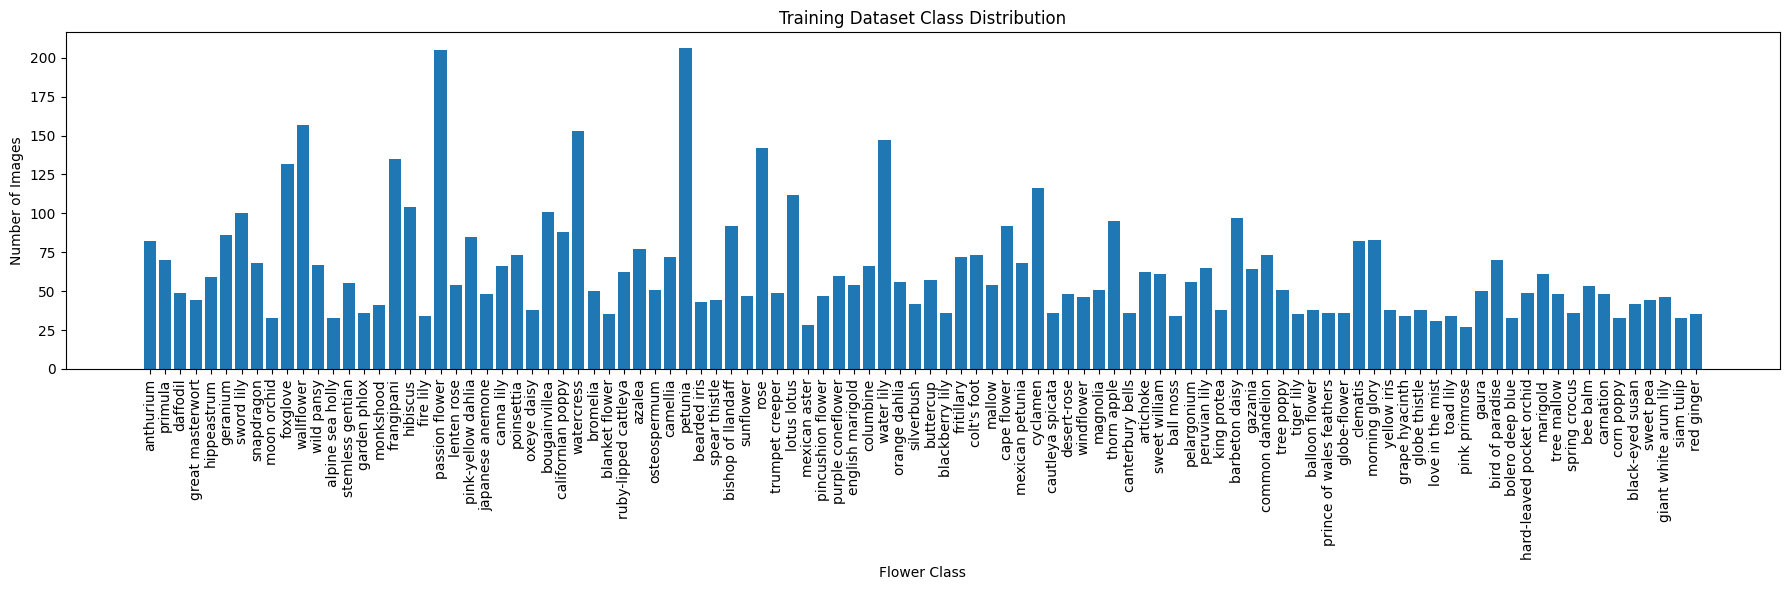

In [ ]:
train_counts = Counter()

for _, label in train_flowers.unbatch():
    train_counts[int(label.numpy())] += 1

names = [idx_to_name[k] for k in train_counts.keys()]
counts = list(train_counts.values())

plt.figure(figsize=(18, 6))
plt.bar(names, counts)
plt.xticks(rotation=90)
plt.xlabel("Flower Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")
plt.tight_layout()
plt.show()


## 3.3 Data Augmentation & Dataset Optimization
To ensure the model generalizes well in images and reduces in overfitting, data augmentation is applied to the training data.

- **Data Augmentation Methods**: Random horizontal flipping, rotation, scaling, brightness and contrast adjustments, translation, etc.

- **Scope of Application**: Apply only to the training set. The validation set remain unchange so that ensuring consistency in evaluation.

<br>

To improve training efficiency, TensorFlow's prefetch technology is used to prepare batches in advance so that GPU/CPU wait times is reduced.

- **Effect**: Accelerates the training process, particularly effective for large-scale image datasets, without compromising model accuracy

In [ ]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(0.2, 0.2),
], name="data_augmentation")

In [ ]:
# Optimize Dataset Performance
normalization = layers.Rescaling(1./255)

def prepare_dataset(ds, augment=False):
    ds = ds.map(lambda x, y: (normalization(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = prepare_dataset(train_flowers, augment=True)
val_ds = prepare_dataset(valid_flowers, augment=False)

AUTOTUNE = tf.data.AUTOTUNE
train_flowers = train_flowers.prefetch(buffer_size=AUTOTUNE)
valid_flowers = valid_flowers.prefetch(buffer_size=AUTOTUNE)

## 3.4 ResNet & MobileNet Preprocessing
Specific image preprocessing is required for the pre-trained models in order to match the input requirements:

- **ResNet50**: Use `resnet_preprocess` to standardize the flower images  

- **MobileNetV2**:  Using `mobilenet_preprocess` to normalize and scale the flower images

These preprocessing steps ensure inputs conform to the specifications used during training of the pretrained weights. This can help to improve effectiveness  of transfer learning.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
def normalize_resnet(image, label):
    return resnet_preprocess(tf.cast(image, tf.float32)), label

train_resnet = train_flowers.map(normalize_resnet, num_parallel_calls=AUTOTUNE).cache().prefetch(buffer_size=AUTOTUNE)
valid_resnet = valid_flowers.map(normalize_resnet, num_parallel_calls=AUTOTUNE).cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
def preprocess_mobilenet(ds):
    return ds.map(lambda x, y: (mobilenet_preprocess(x), y))

train_mb = preprocess_mobilenet(train_flowers)
val_mb   = preprocess_mobilenet(valid_flowers)

# **4. Model 2:** Transfer Learning using ResNet50 (CNN-based) implemented with TensorFlow **[ResNet50 + CNN (TF Transfer)]**
ResNet50 is chosen as the main Convolutional Neural Network (CNN) for the flower classification task for transfer learning. ResNet50 is a deep residual network (ResNet) that contains 50 layers that have been pre-trained on the ImageNet dataset. This allows the network to extract features more efficiently, which in turn helps the model train faster.  

<br>

**Model Objectives**

- Rapidly construct a deep learning model for classifying 102 flower species using pre-trained features.
- Accomplish the classification task with accuracy and robustness using the feature extraction and fine-tuning of the model.

## 4.1 Model Architecture and Transfer Learning Strategy
This model uses ResNet50 as its main CNN, keeping only the convolutional layers for feature extraction.

At the output stage, GlobalAveragePooling, BatchNormalization, and multiple fully connected layers are applied to classify the images into 102 different flower categories.

During the initial's training phase, parameters of ResNet50's convolutional layers was kept fully frozen. Only the newly added classification layers are trained to stabilize the learning process and prevent disruption of the pre-trained features.

In [ ]:
base_model_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_resnet.trainable = False

resnet_model = Sequential([
    base_model_resnet,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
], name='ResNet50_Transfer_Learning')

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Base model trainable: {base_model_resnet.trainable}")
print(f"Total parameters: {resnet_model.count_params():,}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in resnet_model.trainable_weights]):,}")

resnet_model.summary()


Base model trainable: False
Total parameters: 24,804,582
Trainable parameters: 1,211,750


Model: "ResNet50_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 2048)                │           8,192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 102)                 │          26,214 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,804,582 (94.62 MB)

 Trainable params: 1,211,750 (4.62 MB)

 Non-trainable params: 23,592,832 (90.00 MB)

## 4.2 Training Strategy and Optimization

Several optimization strategies were integrated during model training to keep enhancing the generalization ability and training stability, including:

- **Early Stopping:** Based on the validation loss, preventing overfitting in later training stages

- **Learning Rate Scheduling:** Reducing the learning rate when validating performance allow is the model to stabilize and settle into an optimal solutions

- **L2 Regularization + Dropout:** Intentionally topped the model's complexity to prevent any overfitting risks associated with high-capacity networks

These strategies enables the model to achieve high performance within fewer training period.


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)


## 4.3 Initial Training Results (Feature Extraction Phase)

During the feature extraction phase, the convolutional layers of ResNet50 remain frozen, with only the top-level classification network undergoing training.

Training results show that the model achieves validation accuracy exceeding 90% within the first few epochs, significantly outperforming Model 1's scratch-built CNN.

This indicates that pre-trained models possess distinct advantages in terms of capturing different features from the images.

In [ ]:
history_resnet = resnet_model.fit(
    train_resnet,
    validation_data=valid_resnet,
    epochs=20,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 157s 752ms/step - accuracy: 0.3988 - loss: 3.8931 - val_accuracy: 0.8093 - val_loss: 2.2198 - learning_rate: 0.0010
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 145s 708ms/step - accuracy: 0.7341 - loss: 2.2244 - val_accuracy: 0.8888 - val_loss: 1.6542 - learning_rate: 0.0010
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 142s 695ms/step - accuracy: 0.8231 - loss: 1.7932 - val_accuracy: 0.8949 - val_loss: 1.5041 - learning_rate: 0.0010
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 142s 694ms/step - accuracy: 0.8672 - loss: 1.5537 - val_accuracy: 0.9132 - val_loss: 1.4060 - learning_rate: 0.0010
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 143s 697ms/step - accuracy: 0.8945 - loss: 1.4127 - val_accuracy: 0.9218 - val_loss: 1.3149 - learning_rate: 0.0010
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 142s 694ms/step - accuracy: 0.9101 - loss: 1.2995 - val_accuracy: 0.9279 - val_loss: 1.2476 - learning_rate: 0.0010
Epoch 7/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 142s 694ms/step - accura

## 4.4 Fine-tuning Strategy
After the initial training, the model will undergo a **fine-tuning phase** to improve the final outcome.

ResNet50 was partially unfrozen and trained with a lower learning rate, which allowed the network to learn the finer details of the floral dataset while preserving general visual features.

This strategy improved overall performance while reducing instability during training that are caused by large-scale parameter updates.

In [ ]:
base_model_resnet.trainable = True

for layer in base_model_resnet.layers[:-30]:
    layer.trainable = False

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Trainable layers: {sum([1 for layer in resnet_model.layers if layer.trainable])}")
print(f"Total trainable parameters: {sum([tf.size(w).numpy() for w in resnet_model.trainable_weights]):,}")

Trainable layers: 9
Total trainable parameters: 15,661,926


## 4.5 Fine-tuning Results and Performance Evaluation
After fine-tuning, the model achieved a higher validation accuracy as opposed to before fine-tuning phase; the validation accuracy stabilized at **around 96%**.

Early stopping will automatically terminate training when performance is starting to stay static, which effectively stops overfitting in later stages.

In [ ]:
callbacks_resnet_phase2 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1,
        mode='max',
        min_delta=0.001
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-8,
        verbose=1
    )
]

history_resnet_phase2 = resnet_model.fit(
    train_resnet,
    validation_data=valid_resnet,
    epochs=50,
    callbacks=callbacks_resnet_phase2,
    verbose=1
)

Epoch 1/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 189s 898ms/step - accuracy: 0.9212 - loss: 0.7839 - val_accuracy: 0.9401 - val_loss: 0.7607 - learning_rate: 1.0000e-05
Epoch 2/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 183s 892ms/step - accuracy: 0.9589 - loss: 0.6767 - val_accuracy: 0.9450 - val_loss: 0.7526 - learning_rate: 1.0000e-05
Epoch 3/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 183s 894ms/step - accuracy: 0.9689 - loss: 0.6353 - val_accuracy: 0.9499 - val_loss: 0.7379 - learning_rate: 1.0000e-05
Epoch 4/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 183s 894ms/step - accuracy: 0.9776 - loss: 0.6168 - val_accuracy: 0.9450 - val_loss: 0.7281 - learning_rate: 1.0000e-05
Epoch 5/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 183s 892ms/step - accuracy: 0.9858 - loss: 0.5917 - val_accuracy: 0.9511 - val_loss: 0.7292 - learning_rate: 1.0000e-05
Epoch 6/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 183s 891ms/step - accuracy: 0.9860 - loss: 0.5826 - val_accuracy: 0.9462 - val_loss: 0.7216 - learning_rate: 1.0000e-05
Epoch 7/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 

## 4.6 Final Evaluation Results
The final model achieved nearly 100% accuracy on the training data and about 96.6% accuracy on the validation data, showing exceptional feature learning and strong generalization ability.

Compared to Model 1, transfer learning significantly increased the model's performance.

In [ ]:
# Evaluate ResNet50 model
resnet_train_loss, resnet_train_acc = resnet_model.evaluate(train_resnet, verbose=0)
resnet_val_loss, resnet_val_acc = resnet_model.evaluate(valid_resnet, verbose=0)

print("\n" + "="*70)
print("RESNET50 MODEL EVALUATION")
print("="*70)
print(f"Training Accuracy: {resnet_train_acc:.4f}")
print(f"Validation Accuracy: {resnet_val_acc:.4f}")
print(f"Training Loss: {resnet_train_loss:.4f}")
print(f"Validation Loss: {resnet_val_loss:.4f}")


RESNET50 MODEL EVALUATION
Training Accuracy: 1.0000
Validation Accuracy: 0.9658
Training Loss: 0.5012
Validation Loss: 0.6710


## 4.7 Training Visualization and Analysis
The training and validation curves reveal:
- The model converges rapidly during the feature extraction phase.
- Following the initiation of fine-tuning, model performance exhibits a smooth, incremental improvement.
- The narrow gap between training and validation curves indicates that overfitting is well-controlled.

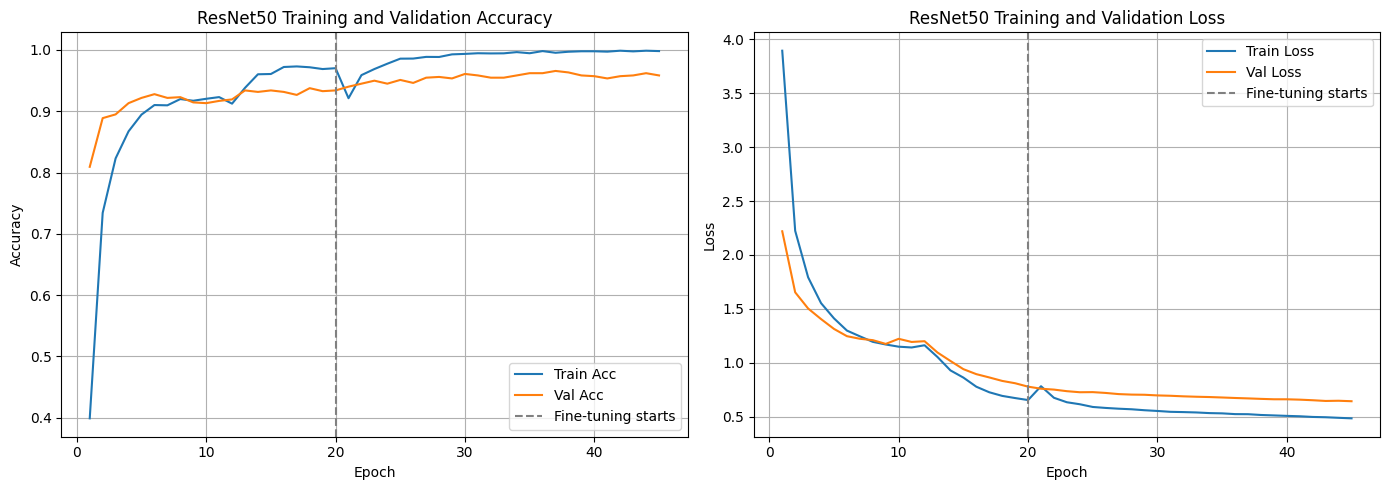

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
initial_epochs = len(history_resnet.history['accuracy'])
finetune_epochs = len(history_resnet_phase2.history['accuracy'])

# --- Accuracy ---
ax1.plot(range(1, initial_epochs + finetune_epochs + 1),
         history_resnet.history['accuracy'] + history_resnet_phase2.history['accuracy'], label='Train Acc')
ax1.plot(range(1, initial_epochs + finetune_epochs + 1),
         history_resnet.history['val_accuracy'] + history_resnet_phase2.history['val_accuracy'], label='Val Acc')
ax1.axvline(x=initial_epochs, color='gray', linestyle='--', label='Fine-tuning starts')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('ResNet50 Training and Validation Accuracy')
ax1.legend()
ax1.grid(True)

# --- Loss ---
ax2.plot(range(1, initial_epochs + finetune_epochs + 1),
         history_resnet.history['loss'] + history_resnet_phase2.history['loss'], label='Train Loss')
ax2.plot(range(1, initial_epochs + finetune_epochs + 1),
         history_resnet.history['val_loss'] + history_resnet_phase2.history['val_loss'], label='Val Loss')
ax2.axvline(x=initial_epochs, color='gray', linestyle='--', label='Fine-tuning starts')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('ResNet50 Training and Validation Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 4.8 Summary
Model 2 shows the power of transfer learning for large-scale image classification problems. With the help of the pre-trained ResNet50 model, the performance of the model improves a considerable amount when compared to the scratch CNN model. This model has set a performance standard for upcoming models, which are the hybrid models and PyTorch-based models.

# **5. Model 3:** Feature Extraction using MobileNet with Support Vector Machine (SVM) and Principal Component Analysis (PCA) for overfitting mitigation **[MobileNetV2 + SVM (Hybrid)]**
Model 3 is implemented by using hybrid learning approach. It combine transfer learning and traditional machine learning (SVM).

This model uses a pre-trained MobileNetV2 to extract image features, then sends those features to an SVM to decide the class.

This method avoid full training of CNNs in order to reduce training time and computational complexity while achieve high accuracy.

<br>

**Model Objectives:**
- Extract high-level image features using MobileNetV2 (ImageNet pre-trained)
- Classify deep features with SVM to enhance generalization capabilities
- Reduce computational resources required for full CNN training
- Minimize overfitting risk through PCA and regularization

## 5.1 Feature Extraction using MobileNetV2

In this stage, MobileNetV2 load **ImageNet weights** and removes the classification layer. This mean only the convolutional backbone network is used to extract features.

Through the **global average pool**, each image is converted into a **1280-dimensional feature vector** for the subsequent SVM training.

All the model parameters are frozen (`trainable = False`) so that the feature extraction stays stable.

In [ ]:
mobilenet = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)
mobilenet.trainable = False

def extract_features(dataset, model):
    features, labels = [], []
    for images, y in dataset:
        f = model(images, training=False)
        features.append(f.numpy())
        labels.append(y.numpy())
    return np.vstack(features), np.concatenate(labels)

X_train_svm, y_train_svm = extract_features(train_mb, mobilenet)
X_val_svm,   y_val_svm   = extract_features(val_mb,   mobilenet)

print(f"Training feature shape: {X_train_svm.shape}")
print(f"Validation feature shape: {X_val_svm.shape}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training feature shape: (6552, 1280)
Validation feature shape: (818, 1280)


## 5.2 SVM Classification
The features are put into and **SVM with an RBF kernel** to do the classification. To make the features standard, **StandardScaler** is used.

The model get a high accuracy on the training set, but it does not do as well on the validation set. This means the accuracy is a bit low when it sees new data. This shows that the model has some overfitting.

In [ ]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc",    SVC(kernel="rbf", C=10, gamma="scale", verbose=True))
])

svm_model.fit(X_train_svm, y_train_svm)

svm_train_preds = svm_model.predict(X_train_svm)
svm_val_preds   = svm_model.predict(X_val_svm)

train_accuracy_svm = accuracy_score(y_train_svm, svm_train_preds)
val_accuracy_svm   = accuracy_score(y_val_svm,   svm_val_preds)

print(f"\nMobileNetV2 + SVM Training Accuracy: {train_accuracy_svm:.4f}")
print(f"MobileNetV2 + SVM Validation Accuracy: {val_accuracy_svm:.4f}")

[LibSVM]
MobileNetV2 + SVM Training Accuracy: 1.0000
MobileNetV2 + SVM Validation Accuracy: 0.8753


## 5.3 Overfitting Analysis
By looking at the training accuracy and the validation accuracy, there is a big gap between the two scores. This shows that the model overfits the training data.

This usually happens when high-dimensional deep features are used with strong classifiers like SVM.

In [ ]:
print(f"\n{'='*60}")
print(f"MobileNetV2 + SVM: Overfitting & Underfitting Analysis")
print(f"{'='*60}")
print(f"Training Accuracy: {train_accuracy_svm:.4f}")
print(f"Validation Accuracy: {val_accuracy_svm:.4f}")
print(f"Accuracy Gap: {train_accuracy_svm - val_accuracy_svm:.4f}")

print(f"\nDIAGNOSIS:")
if train_accuracy_svm > 0.9 and (train_accuracy_svm - val_accuracy_svm) > 0.15:
    print("Overfitting")
elif train_accuracy_svm < 0.6 and val_accuracy_svm < 0.6:
    print("Underfitting")
elif abs(train_accuracy_svm - val_accuracy_svm) < 0.05:
    print("Good fit")
else:
    print("Slight overfitting")


MobileNetV2 + SVM: Overfitting & Underfitting Analysis
Training Accuracy: 1.0000
Validation Accuracy: 0.8753
Accuracy Gap: 0.1247

DIAGNOSIS:
Slight overfitting


## 5.4 Performance Visualization
The bar chart show the training accuracy, validation accuracy, and the accuracy gap. It is an easy way to see the model's generalization capability.

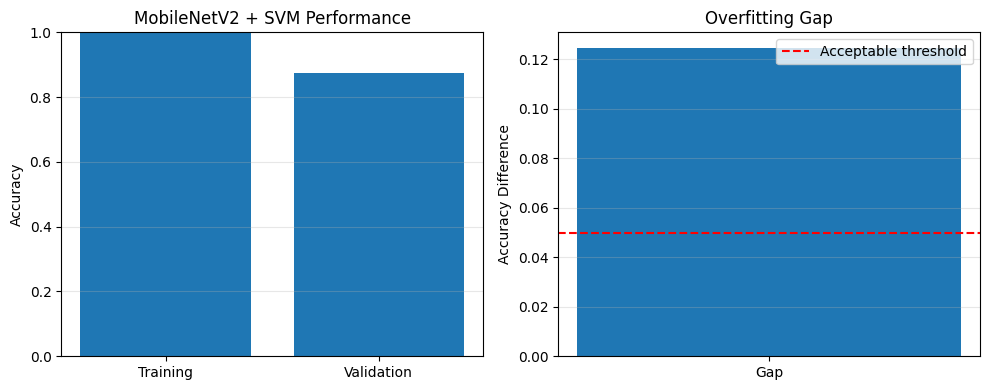

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(['Training', 'Validation'], [train_accuracy_svm, val_accuracy_svm])
plt.ylabel('Accuracy')
plt.title('MobileNetV2 + SVM Performance')
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(['Gap'], [train_accuracy_svm - val_accuracy_svm])
plt.ylabel('Accuracy Difference')
plt.title('Overfitting Gap')
plt.axhline(y=0.05, color='r', linestyle='--', label='Acceptable threshold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5.5 Model Improvement Using PCA
To mitigate overfitting, the model use **Principal Component Analysis (PCA)** to make the feature dimensions smaller, down to 256. It also changes to a **linear SVM** and uses a smaller regularization parameter.


This improvement effectively enhances validation accuracy while narrowing the accuracy gap.


In [ ]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=256)),
    ("svc",    SVC(kernel="linear", C=0.5))
])

svm_model.fit(X_train_svm, y_train_svm)

train_preds = svm_model.predict(X_train_svm)
val_preds   = svm_model.predict(X_val_svm)

train_accuracy = accuracy_score(y_train_svm, train_preds)
val_accuracy   = accuracy_score(y_val_svm,   val_preds)

print(f"\n{'='*60}")
print(f"MobileNetV2 + SVM - Improved by using PCA and Regularization")
print(f"{'='*60}")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Gap: {train_accuracy - val_accuracy:.4f}")


MobileNetV2 + SVM - Improved by using PCA and Regularization
Training Accuracy: 1.0000
Validation Accuracy: 0.9046
Gap: 0.0954


## 5.6 Summary
In Model 3, the efficacy of deep feature extraction with traditional classifiers is shown. Although overfitting problems were observed with the initial model, the generalization performance was greatly improved with PCA and regularization. This approach offers a good trade-off between efficiency and performance, although it is still restricted to its current features.

# **6. Model 4:** Transfer Learning using ResNet18 with Multi-Layer Perceptron (MLP) classifier implemented in PyTorch **[ResNet18 + MLP (PyTorch)]**
Model 4 uses a transfer learning architecture, utilizes pre-trained ResNet18 as the convolutional feature extractor, and combines it with PyTorch-based MLP classifier to carry on flower classification. This model does not need to learn low-level visual features from scratch because ResNet18 convolutional layers are frozen. It turns to focus on learning the patterns of identify different flowers classification through MLP, thereby enhances the model stability and training efficiency.

<br>

**Model Objectives:**
- Utilize pre-trained ResNet18 to extract high-level image features, reducing training costs
- Learn discriminative boundaries between flower categories via an MLP classifier
- Minimize overfitting risk and enhance generalization capabilities by freezing convolutional layers
- Build stable and efficient classification models using the PyTorch framework


### 6.1 Import PyTorch Library

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [ ]:
# Use the GPU if it is available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


### 6.2 Image Preprocessing Pipeline
Data preprocessing is all about make sure the input images follow the rules of the ResNet architecture. This is done through a few specific steps:

- **Resizing:** All images are changed to a fixed resolution so they are all the same size.

- **Normalization:** The images are normalized that using the specific ImageNet mean and standard deviation values.

These steps help make the training more stable and ensure everything is compatible with the pre-trained ResNet feature extractor.


In [ ]:
torch_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### 6.3 Load Dataset
##### Although the previous models had their datasets loaded using TensorFlow, the model 4 is implemented entirely in Pytorch. TensorFlow and PyTorch use different data structures and tensor representations so the dataset was reloaded using PyTorch's ImageFolder and DataLoader. This ensures the full compatibility wite the PyTorch training pipeline. While it can make sure all models's directory structure, image resolution, batch size, and class labels are maintining consistency.



In [ ]:
# Load Dataset
train_data = datasets.ImageFolder(train_dir, transform=torch_transform)
val_data   = datasets.ImageFolder(val_dir, transform=torch_transform)

# Create dataLoader for training and validation data
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

num_classes = len(train_data.classes)
print("Number of classes:", num_classes)

Number of classes: 102


### 6.4 ResNet Feature Extractor and MLP Classifier (ANN Component)
A pre-trained ResNet18 model works as the convolutional backbone. All the convolutional layers are frozen to keep the learned features and stop overfitting. The original fully connected layer is taken out so the network can output a 512-dimensional feature vector.
The feature extractor can extract advanced details from images while maintaining fast processing speed and high computing efficiency.

The features from the first part are sent to a Multi-Layer Perceptron (MLP) classifier, which includes:

- A fully connected hidden layer with 256 neurons.
- The ReLU activation function.
- A Dropout rate of 0.5 for regularization.
- A final output layer with 102 neurons for each of the flower classes.

During training, only the parts of the MLP classifier are actually updated.

In [ ]:
class ResNetMLP(nn.Module):
    def __init__(self, num_classes):
        super(ResNetMLP, self).__init__()

        # Load pretrained ResNet18
        self.backbone = models.resnet18(pretrained=True)

        # Freeze CNN layers (feature extractor)
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Get number of input feature (512 for ResNet18)
        in_features = self.backbone.fc.in_features

        # Remove original FC layer
        self.backbone.fc = nn.Identity()

        # Define a custom MLP classifier
        self.mlp = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)   # Extract Features using ResNet
        x = self.mlp(x)        # Classify features using MLP
        return x

- For the target function, the model uses Cross-Entropy loss. This is good for multi-class image classification with 102 flower categories. For the optimization, the Adam optimizer is used, but only for the MLP classifier part.

- Because of the ResNet feature extractor is frozen and only the classifier is updated, the model can get faster convergence and stable training. This also helps keep the high quality of the pre-trained visual features.

In [ ]:
# Initial the ResNet and MLP model, then define the loss function for the multi-class classification, and set up Adam Optimizer to train only the MLP classifier parameters
model = ResNetMLP(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.mlp.parameters(), lr=1e-3)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\lowsa/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


C:\Users\lowsa\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\lowsa\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100.0%


ResNetMLP(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_

## 6.5 Training and Evaluation
The model 4 uses a two-stage design. It starts with a ResNet-based convolutional feature extractor and ends with an ANN-based classifier.

In [ ]:
EPOCHS = 200
PATIENCE = 15

best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0
best_model_state = None

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

- In order to prevent the model from remembering data like overfitting or wasting time, the use of early-stopping is according to the validation loss and the patience value is 15 epoch.
- If the validation performance is no longer improved, the training will be stopped automatically.
- In this experiment, the early-stopping was triggered at the epoch 45, which indicates that the model reached its best performance long before the completion of 200 epochs.


In [ ]:
for epoch in range(EPOCHS):
    # TRAIN
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

  # Compute the average taining loss and accuracy
    train_loss /= len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    # VALIDATION
    model.eval()    # Set model to evaluation mode
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    # Save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"loss: {train_loss:.4f}, "
        f"acc: {train_accuracy:.2f}% | "
        f"val_loss: {val_loss:.4f}, "
        f"val_acc: {val_accuracy:.2f}%"
    )

    # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

Epoch [1/200] | loss: 3.5978, acc: 21.43% | val_loss: 2.0717, val_acc: 54.16%
Epoch [2/200] | loss: 1.9374, acc: 51.80% | val_loss: 1.0805, val_acc: 75.92%
Epoch [3/200] | loss: 1.4100, acc: 62.56% | val_loss: 0.7981, val_acc: 82.27%
Epoch [4/200] | loss: 1.1693, acc: 67.84% | val_loss: 0.6695, val_acc: 84.23%
Epoch [5/200] | loss: 1.0050, acc: 72.16% | val_loss: 0.5610, val_acc: 85.94%
Epoch [6/200] | loss: 0.8877, acc: 75.08% | val_loss: 0.5350, val_acc: 86.80%
Epoch [7/200] | loss: 0.8406, acc: 75.84% | val_loss: 0.4897, val_acc: 86.80%
Epoch [8/200] | loss: 0.7731, acc: 77.84% | val_loss: 0.4999, val_acc: 86.43%
Epoch [9/200] | loss: 0.7167, acc: 79.37% | val_loss: 0.4409, val_acc: 87.90%
Epoch [10/200] | loss: 0.6614, acc: 80.60% | val_loss: 0.4456, val_acc: 88.14%
Epoch [11/200] | loss: 0.6669, acc: 80.39% | val_loss: 0.4320, val_acc: 87.78%
Epoch [12/200] | loss: 0.6214, acc: 81.94% | val_loss: 0.4314, val_acc: 87.90%
Epoch [13/200] | loss: 0.6126, acc: 81.29% | val_loss: 0.4098

- During the training process, training accuracy went up steadily to about 89.5%, while validation accuracy stayed high at around 90%. The training and validation accuracy score are very close. This shows that the model has a good generalization ability for new data.

- Basically, it mean that the model is not just memorizing the pictures it already saw.

- At the same time, the training and validation loss values dropped fast at the beginning and leveled off later. This shows the model has a smooth and stable convergence.


In [ ]:
# Check for overfitting
final_train_acc = train_accuracies[-1]
final_val_acc = val_accuracies[-1]
final_train_loss = train_losses[-1]
final_val_loss = val_losses[-1]

acc_gap = final_train_acc - final_val_acc
loss_gap = final_val_loss - final_train_loss

if acc_gap > 10 and loss_gap > 0.5:
    print("\nOverfitting")
elif final_train_acc < 70 and final_val_acc < 70:
    print("\nUnderfitting")
else:
    print("\nWell-balanced")


Well-balanced


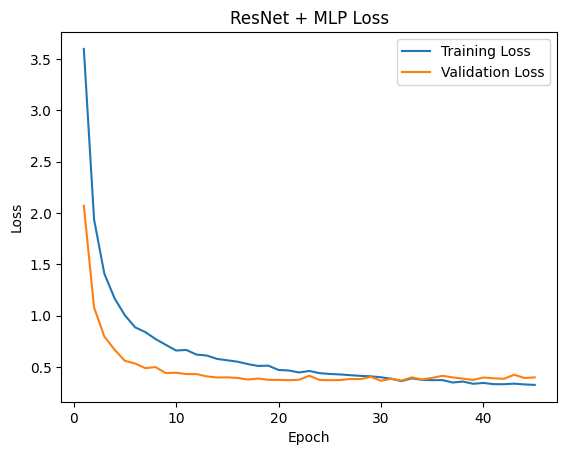

In [ ]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs_range, train_losses, label="Training Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet + MLP Loss")
plt.legend()
plt.show()

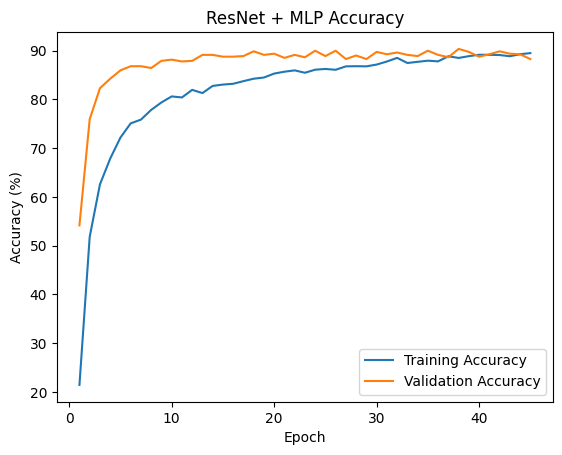

In [ ]:
plt.figure()
plt.plot(epochs_range, train_accuracies, label="Training Accuracy")
plt.plot(epochs_range, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet + MLP Accuracy")
plt.legend()
plt.show()

## 6.6 Summary
Model 4 show that the effectiveness of transfer learning by combining a frozen ResNet18 feature extractor and MLP classifier. The model relies on its limited number of trainable parameter as well as early stopping, achieved a strong generalization performance with minimal overfitting. This approach accomplish a balance between training efficiency and classifying accuracy, but the performance still restricted by the fixed pre-trained features.

# **7. Model Comparison and Summarization**

## 7.1 Model Summarization

### Model Comparison Summary

| **Criteria** | **Model 1: CNN from Scratch (TF)** | **Model 2: ResNet50 + CNN (TF Transfer)** | **Model 3: MobileNetV2 + SVM (Hybrid)** | **Model 4: ResNet18 + MLP (PyTorch)** |
|-------------|-----------------------------------|------------------------------------------|----------------------------------------|--------------------------------------|
| **Framework** | TensorFlow | TensorFlow | TensorFlow + Scikit-learn | PyTorch |
| **Approach** | Trained from Scratch | Transfer Learning | Hybrid: CNN Feature Extraction + SVM | Transfer Learning + MLP Head |
| **Pre-trained Backbone** | None | ResNet50 (ImageNet) | MobileNetV2 (ImageNet) | ResNet18 (ImageNet) |
| **Feature Extractor** | 3-layer Custom Conv Stack | ResNet50 Conv Layers | MobileNetV2 (frozen, pooling = avg) | ResNet18 Conv Layers |
| **Classifier Head** | Dense(256) → Dense(102) | Dense(512) → Dense(256) → Dense(102) | SVM (RBF kernel, improved with PCA + Linear kernel) | MLP: Linear(256) → ReLU → Linear(102) |
| **Fine-tuning** | N/A (trained end-to-end) | Yes (Phase 2: top 30 layers unfrozen) | No (backbone frozen) | No (backbone frozen) |
| **Training Accuracy** | 0.5462 | 1 | 1 | 0.8948 |
| **Validation Accuracy** | 0.5122 | 0.9658 | 0.9046 | 0.8826 |
| **Overfitting Risk** | Underfitting (insufficient capacity) | Controlled (L2 + Dropout + Early Stopping) | Slight overfitting (RBF); reduced after PCA | Well-balanced (Early Stopping) |
| **Number of Parameters** | ~1.2M (custom 3-layer CNN) | ~24.8M (ResNet50 base + dense heads) | ~3.4M (MobileNetV2) + negligible SVM parameters | ~11.2M (ResNet18 base + MLP head) |
| **Regularisation Used** | L2 (0.001), Dropout (0.5), Early Stopping | L2 (0.001), Dropout (0.5, 0.4), BatchNorm | StandardScaler, PCA (256 dims), C = 0.5 (linear) | Dropout (0.5), Early Stopping |


## 7.2 Strengths and Limitations of Each Model


| **Model** | **Strengths** | **Limitations** |
|-----------|---------------|-----------------|
| **Model 1: CNN from Scratch** | • Everything need to be designed manually<br> • Lightweight, only 1.2M parameters, so it run fast<br> • Do not use any pre-trained knowledge | • Poor generalization, only 52% val acc<br>• Low capacity cause underfit<br>• Long model training time  |
| **Model 2: ResNet50 + CNN** | •Best performance overall, 96.6% accuracy<br>• Use knowledge learned from ImageNet<br>• Training in 2 phase to improve performance<br>• Strong regularization, so that handle similar flower classes well  | • Computationally expensive, which is ~24.8M parameters<br>• Need careful fine-tuning to avoid bad performance<br>• Longer model training time compare to CNN from scratch|
| **Model 3: MobileNetV2 + SVM** | • No full neural network training needed<br>• Fast after feature extraction<br>• SVM is easier to explain and understand than deep models<br>• Memory is used efficiently   | • Initial RBF kernel overfits (100% train, 90.5% val)<br>• Requires manual feature engineering (PCA tuning)<br>• Performance ceiling lower than fine-tuned CNNs<br>• Cannot adapt backbone to domain-specific features<br>• SVM training time scales poorly with large datasets |
| **Model 4: ResNet18 + MLP** | • Well-balanced performance (88% validation accuracy)<br>• PyTorch implementation offers flexibility<br>• Frozen backbone reduces overfitting<br>• Early stopping ensures efficient training<br>• Lightweight MLP classifier is easy to modify | • Lower accuracy than Model 2 (no fine-tuning)<br>• Smaller ResNet18 backbone (vs ResNet50) extracts less complex features<br>• Fixed feature representation limits domain adaptation<br>• Performance plateau due to frozen convolutional layers<br>• Dependent on quality of pre-trained features |



## 7.3 Transfer Learning and Training from Scratch

- The most significant contrast in this project is between CNN trained from scratch,which is model 1,  and models that leverage pre-trained weights, which are model 2,3 and 4.

- There is very clear observation that the models that leverage pre-trained weights all achieved meaningfully higher validation accuracy than model 1. This is due to inter-class similarity. With 102 visually similar flower classes and relatively small per-class training set, a model that was built from scratch does not have enough data to learn the fine-grained visual distinctions on its own.

- Pre-trained models already know how to recognise basic and medium-level visual patterns, such as edges, textures, and colour changes, as they were trained on the large ImageNet dataset. Model 1 poor performance confirms that for fine-grained classification tasks with limited data, transfer learning is almost necessary.


# **8. Discussion**

## 8.1. The Role of Fine-Tuning

Among all models in this project, model 2 is the only one that performs fine-tuning on the backbone itself. During Phase 2, the top 30 layers are unfrozen, allowing the convolutional filters to adapt the flower-specific features. Consequently, this produces the highest validation accuracy of all 4 models. Model 3 and 4, which keep their backbones completely frozen, perform well but do not reach the same level. This shows that while frozen pre-trained features are a strong starting point, fine-tuning the upper layers to specialize for the target domain provides a significant accuracy boost. The careful use of low learning rate, 1e-5, and EarlyStopping during fine-tuning is important as it prevents the model from forgetting the useful features it learned earlier. Without these controls, the pre-trained features could be overwritten if the learning rate is too high or fine-tuning is uncontrolled.

## 8.2. Hybrid CNN and Classical Classifier

By using MobileNetV2 only as a feature extractor and a SVM to do the classification, heavy computation of training the whole network while still using the strong features learned by a pre-trained model is avoided. The Radial Basis Function (RBF) kernel lets an SVM draw curved and flexible boundaries between classes instead of simple straight lines. RBF kernel gives good accuracy but shows slight overfitting as RBF kernel with a high C value can fit the training data too closely and “memorize” it. The improved pipeline, which is PCA,  dimensionality reduction followed by a linear SVM with lower C value. Consequently, the gap between training and validation accuracy becomes smaller.

To sum up for this model, controlling overfitting is important not only for neural networks, but also for traditional classifiers like SVM.

## 8.3. Overfitting and Generalization

- Model 1 is the only model that underfits as the
three layer CNN is too simple and does not have enough capacity to learn 102 detailed classes.
- Model 2 achieves the best balance between training and validation accuracy due to its multi-layered regularization strategy, which are L2 weight decay, Dropout at 2 levels, BatchNormalization and EarlyStopping with the best weights restored during two training phases.
- Model 3 starts with slight overfitting when using an RBF SVM. After applying PCA and switching to a linear SVM, the model becomes more balanced. This shows that reducing feature dimensions is an effective way to control overfitting in the classifier.  
- Model 4 is well-balanced as only the small MLP classifier is trained, while the large pre-trained backbone is frozen. This limits the model’s ability to memorize the training data.

Overall, the use of EarlyStopping proves to be the single most consistently as it directly prevents overfitting by preserving the best-performing checkpoint.


# **9. Conclusion**

This study presents a comparative evaluation of four distinct model architectures for 102-class flower species classification using the Oxford 102 Flower Dataset. The results show that the model gets better as it gets more complex and uses more pre-trained knowledge.

---

### **Model 1 (CNN from scratch)**

The scratch CNN model acts as a baseline. However, the accuracy reached only approximately 52% for the validation accuracy. Its limited capacity and the absence of prior visual knowledge made it insufficient for distinguishing among 102 visually similar flower classes, even after applying data augmentation, L2 regularization, and learning rate scheduling. This shows that training deep CNNs from scratch on pre-trained classification tasks with limited per-class data is very challenging.

### **Model 2 (ResNet50 + CNN (TF Transfer))**

Gets the highest validation accuracy at approximately 96.6%. The initial feature extraction phase rapidly reached over 90% accuracy. Unfreezing and fine-tuning the top 30 convolutional layers helped the model adjust what it learned so it could better recognize flower-specific features. This shows advantage of fine-tuning over using frozen pre-trained backbones alone.

### **Model 3 (MobileNetV2 + SVM (Hybrid))**

When the RBF-kernel SVM shows overfitting, the application of PCA for dimensionality reduction and a switch to a regularized linear SVM substantially reduce the generalization gap, achieve a validation accuracy of approximately 90.5%. This highlights that overfitting control is important in traditional classifiers as it is in neural networks. Its simplicity and training efficiency make it a practical choice when computational resources are limited.

### **Model 4 (ResNet18 + MLP (PyTorch))**

Get around 88% validation accuracy with well-balanced training and validation performance. Its frozen backbone restricts its ability to adapt to domain-specific features.

---

Among all models, EarlyStopping was the most reliable method to prevent overfitting. The use of pre-trained ImageNet weights was the single largest factor contributing to improved performance. The findings prove that transfer learning is necessary for fine-grained image classification. Also, fine-tuning the top layers of a pre-trained model works best if you use the right regularization. Overall, this study shows that choosing the right model and using pre-trained knowledge are very important. It helps the model tell the difference between flower species that look very similar.